In [1]:
import pandas as pd
import numpy as np
import yaml
import cv2
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# load tracks (pixels)
df = pd.read_csv(ROOT / "outputs/trajectories/camera1_tracks.csv")

# load homography
with open(ROOT / "configs/camera_01.yaml") as f:
    cfg = yaml.safe_load(f)
H = np.array(cfg["homography"], dtype=np.float32)

# project all foot positions to metres in one batch
pts = df[["cx", "cy"]].values.astype(np.float32).reshape(-1, 1, 2)
metres = cv2.perspectiveTransform(pts, H).reshape(-1, 2)
df["x_m"] = metres[:, 0]
df["y_m"] = metres[:, 1]

print(df.head())
print(f"\n{len(df)} rows, {df['track_id'].nunique()} unique tracks")
print(f"x_m range: {df['x_m'].min():.1f} to {df['x_m'].max():.1f}")
print(f"y_m range: {df['y_m'].min():.1f} to {df['y_m'].max():.1f}")

   frame  track_id     class   conf      cx    cy       x_m        y_m
0    325         2  forklift  0.559  1022.7  93.8  1.832739  10.144015
1    326         2  forklift  0.620  1022.7  93.7  1.832731  10.146650
2    327         2  forklift  0.658  1022.5  94.4  1.829614  10.128369
3    328         2  forklift  0.677  1022.3  95.1  1.826503  10.110126
4    329         2  forklift  0.675  1021.7  96.1  1.817100  10.084366

549 rows, 4 unique tracks
x_m range: 1.1 to 3.5
y_m range: -0.2 to 10.1


In [2]:
# --- Frame rate: needed to convert Δposition/Δframe into m/s ---
import cv2
cap = cv2.VideoCapture(str(ROOT / "evaluation_videos/cctv/Camera1.mp4"))
FPS = cap.get(cv2.CAP_PROP_FPS)
cap.release()
print(f"Video FPS: {FPS}")

# --- Class-lock: each track gets ONE class by majority vote over its life ---
locked = df.groupby("track_id")["class"].agg(lambda s: s.value_counts().index[0])
df["class"] = df["track_id"].map(locked)
print("\nLocked classes per track:")
print(locked)

# --- Time column ---
df = df.sort_values(["track_id", "frame"]).reset_index(drop=True)
df["t"] = df["frame"] / FPS

# --- Velocity per track (metres/second), computed within each track ---
df["vx"] = df.groupby("track_id")["x_m"].diff() / df.groupby("track_id")["t"].diff()
df["vy"] = df.groupby("track_id")["y_m"].diff() / df.groupby("track_id")["t"].diff()

# --- Smooth velocity (rolling mean, 5 frames) to kill tracker jitter ---
df["vx"] = df.groupby("track_id")["vx"].transform(lambda s: s.rolling(5, min_periods=1, center=True).mean())
df["vy"] = df.groupby("track_id")["vy"].transform(lambda s: s.rolling(5, min_periods=1, center=True).mean())

# --- Speed magnitude ---
df["speed"] = np.sqrt(df["vx"]**2 + df["vy"]**2)

# --- Sanity: speed by class (forklift 2-4 m/s, pedestrian 1-1.6 m/s expected) ---
print("\nSpeed (m/s) by class:")
print(df.groupby("class")["speed"].describe()[["mean", "min", "max"]])

Video FPS: 24.0

Locked classes per track:
track_id
2    forklift
3    forklift
4    forklift
5    forklift
Name: class, dtype: str

Speed (m/s) by class:
              mean       min       max
class                                 
forklift  0.660152  0.007281  5.036556


In [3]:
# Reorder to clean schema and save
cols = ["frame", "t", "track_id", "class", "x_m", "y_m", "vx", "vy", "speed", "conf"]
corpus = df[cols].copy()

out_path = ROOT / "outputs/trajectories/camera1_corpus.csv"
corpus.to_csv(out_path, index=False)
print(f"Saved trajectory corpus: {out_path}")
print(f"{len(corpus)} rows, {corpus['track_id'].nunique()} tracks")
print(corpus.head())

Saved trajectory corpus: /Users/aayushaswal/aisleguard/outputs/trajectories/camera1_corpus.csv
549 rows, 4 tracks
   frame          t  track_id     class       x_m        y_m        vx  \
0    325  13.541667         2  forklift  1.832739  10.144015 -0.037504   
1    326  13.583333         2  forklift  1.832731  10.146650 -0.049891   
2    327  13.625000         2  forklift  1.829614  10.128369 -0.093835   
3    328  13.666667         2  forklift  1.826503  10.110126 -0.089746   
4    329  13.708333         2  forklift  1.817100  10.084366 -0.067017   

         vy     speed   conf  
0 -0.187752  0.191461  0.559  
1 -0.271111  0.275663  0.620  
2 -0.357897  0.369993  0.658  
3 -0.411012  0.420696  0.677  
4 -0.412198  0.417610  0.675  


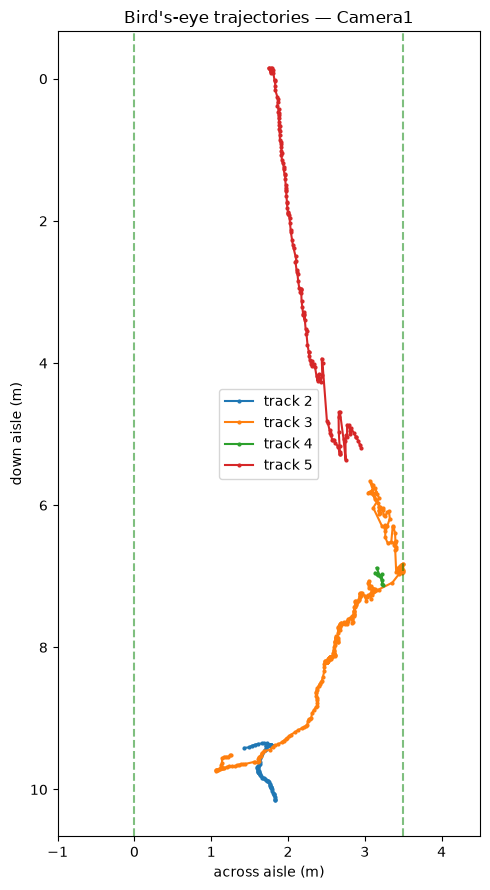

Saved BEV plot


In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 9))
for tid, g in corpus.groupby("track_id"):
    ax.plot(g["x_m"], g["y_m"], marker="o", markersize=2, label=f"track {tid}")

# draw aisle bounds
ax.axvline(0, color="green", ls="--", alpha=0.5)
ax.axvline(3.5, color="green", ls="--", alpha=0.5)
ax.set_xlabel("across aisle (m)")
ax.set_ylabel("down aisle (m)")
ax.set_title("Bird's-eye trajectories — Camera1")
ax.set_xlim(-1, 4.5)
ax.legend()
ax.invert_yaxis()   # so near=bottom matches the video
plt.tight_layout()
plt.savefig(ROOT / "outputs/trajectories/camera1_bev.png", dpi=100)
plt.show()
print("Saved BEV plot")